<h1>---------------🖋️SIGNATURE VERIFICATION USING DEEP LEARNING---------------</h1>

## TABLE OF CONTENTS:
1. Project Objectives
2. Problem Statement
3. Import Libraries
4. Load Dataset
5. Dataset Count
6. Image Visualization
7. Image Preprocessing
8. CNN Input Shape Preparation
9. Signer-wise Data Splitting
10. Check Class Dsitribution
11. Bulid CNN Model
12. Compile the CNN Model
13. Model Completion and Training Callbacks
14. Create Train-Validation Split
15. Create Actual,Validation & Test Data
16. Calculate the Class Weights
17. Train the CNN Model
18. Training & Validation Graphs
19. Evaluate the Fianl CNN model
20. Confusion Matrix
21. Classification Report
22. Single Signature Prediction
23. Conclusion
24. Project Limitations
25. Future Enchancements

## 1.Project Objectives:

1. To develop a deep learning model for signature verification.
2. To classify signature images into genuine and forgery classes.
3. To preprocess and normalize signature images for CNN-based learning.
4. To extract important visual patterns automatically using Convolutional Neural Networks.
5. To evaluate the model using accuracy, precision, recall, F1-score and confusion matrix.
6. To predict whether a new signature is genuine or forged.


## 2.Problem Statement:
Manual signature verification is time-consuming and may be difficult when signatures have small variations. Therefore, this project aims to develop a deep learning-based system that can automatically distinguish between genuine and forged signatures from signature images.”

## 3.Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

print("All libraries imported successfully!")

All libraries imported successfully!


## 4.Load Dataset

In [2]:
dataset_path = r"C:\Users\reena\Downloads\IMARTICUS\PERSONAL PROJECTS\DEEP LEARNING\UTSig_Resize\SigResize"

print("Dataset Path:", dataset_path)
print("Folders:", os.listdir(dataset_path))

Dataset Path: C:\Users\reena\Downloads\IMARTICUS\PERSONAL PROJECTS\DEEP LEARNING\UTSig_Resize\SigResize
Folders: ['.DS_Store', 'Forgery', 'Genuine']


## 5.Dataset Count

In [3]:
import os

genuine_path = os.path.join(dataset_path, "Genuine")
forgery_path = os.path.join(dataset_path, "Forgery")

genuine_images = []
for root, dirs, files in os.walk(genuine_path):
    for file in files:
        if file.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg')):
            genuine_images.append(os.path.join(root, file))

forgery_images = []
for root, dirs, files in os.walk(forgery_path):
    for file in files:
        if file.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg')):
            forgery_images.append(os.path.join(root, file))

print("Genuine Images :", len(genuine_images))
print("Forgery Images :", len(forgery_images))
print("Total Images   :", len(genuine_images) + len(forgery_images))

Genuine Images : 3105
Forgery Images : 5175
Total Images   : 8280


**Observation:**

1.The dataset contains 8,280 signature images, including 3,105 genuine and 5,175 forged signatures.

2.The dataset is imbalanced because the number of forged signatures is higher than genuine signatures.


## 6.Image Visualization

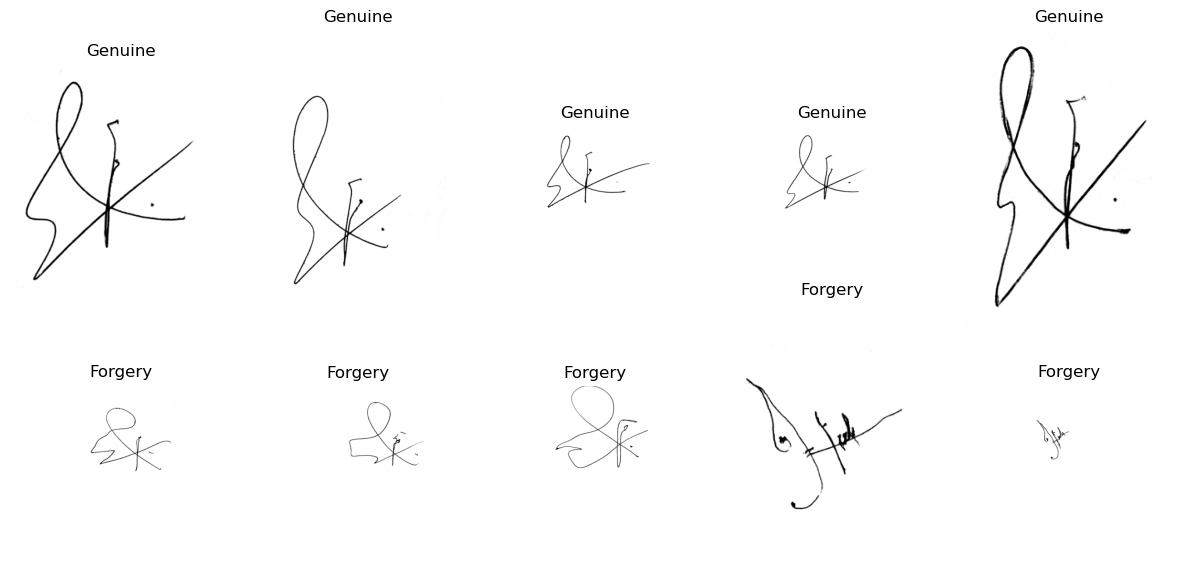

In [4]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12, 6))

# Genuine images
for i in range(5):
    img = cv2.imread(genuine_images[i], cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title("Genuine")
    plt.axis("off")

# Forgery images
for i in range(5):
    img = cv2.imread(forgery_images[i], cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(2, 5, i + 6)
    plt.imshow(img, cmap='gray')
    plt.title("Forgery")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Observation:**
Sample images show that genuine and forged signatures can have visual similarities, making automated classification a challenging task.

## 7.Image Preprocessing

In [5]:
IMG_SIZE = 128

X = []
y = []

# Genuine = 0
for img_path in genuine_images:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        
        X.append(img)
        y.append(0)

# Forgery = 1
for img_path in forgery_images:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        
        X.append(img)
        y.append(1)

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

X Shape: (8280, 128, 128)
y Shape: (8280,)
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


**Observation:**
All 8,280 signature images were successfully preprocessed by converting them to grayscale, resizing them to 128×128 pixels, and normalizing pixel values between 0 and 1. Genuine signatures were labeled as 0 and forged signatures as 1. The final image array shape was (8280, 128, 128), confirming that the preprocessing was completed successfully.”

## 8.CNN Input Shape Preparation

In [6]:
X = X.reshape(-1, 128, 128, 1)

print("New X Shape:", X.shape)

New X Shape: (8280, 128, 128, 1)


**Observation:**
The images were reshaped to 128 × 128 × 1, where 1 represents the single grayscale channel required by the CNN.

## 9.Signer-Wise Data Splitting

In [7]:
#Data Structure Analysis

print("Sample Genuine Path:")
print(genuine_images[0])

print("\nSample Forgery Path:")
print(forgery_images[0])

Sample Genuine Path:
C:\Users\reena\Downloads\IMARTICUS\PERSONAL PROJECTS\DEEP LEARNING\UTSig_Resize\SigResize\Genuine\1\1.tif

Sample Forgery Path:
C:\Users\reena\Downloads\IMARTICUS\PERSONAL PROJECTS\DEEP LEARNING\UTSig_Resize\SigResize\Forgery\Opposite Hand\1\1.tif


In [8]:
print("Genuine Subfolders:")
print(os.listdir(genuine_path))

print("\nForgery Subfolders:")
print(os.listdir(forgery_path))

Genuine Subfolders:
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']

Forgery Subfolders:
['Opposite Hand', 'Simple', 'Skilled']


In [9]:
#Inspect how many images each signer has..

from collections import Counter

genuine_signers = []

for path in genuine_images:
    parts = path.split(os.sep)
    signer_id = parts[-2]
    genuine_signers.append(signer_id)

signer_counts = Counter(genuine_signers)

print("Number of Signers:", len(signer_counts))
print("\nImages per Signer:")
print(signer_counts)

Number of Signers: 115

Images per Signer:
Counter({'1': 27, '10': 27, '100': 27, '101': 27, '102': 27, '103': 27, '104': 27, '105': 27, '106': 27, '107': 27, '108': 27, '109': 27, '11': 27, '110': 27, '111': 27, '112': 27, '113': 27, '114': 27, '115': 27, '12': 27, '13': 27, '14': 27, '15': 27, '16': 27, '17': 27, '18': 27, '19': 27, '2': 27, '20': 27, '21': 27, '22': 27, '23': 27, '24': 27, '25': 27, '26': 27, '27': 27, '28': 27, '29': 27, '3': 27, '30': 27, '31': 27, '32': 27, '33': 27, '34': 27, '35': 27, '36': 27, '37': 27, '38': 27, '39': 27, '4': 27, '40': 27, '41': 27, '42': 27, '43': 27, '44': 27, '45': 27, '46': 27, '47': 27, '48': 27, '49': 27, '5': 27, '50': 27, '51': 27, '52': 27, '53': 27, '54': 27, '55': 27, '56': 27, '57': 27, '58': 27, '59': 27, '6': 27, '60': 27, '61': 27, '62': 27, '63': 27, '64': 27, '65': 27, '66': 27, '67': 27, '68': 27, '69': 27, '7': 27, '70': 27, '71': 27, '72': 27, '73': 27, '74': 27, '75': 27, '76': 27, '77': 27, '78': 27, '79': 27, '8': 27, 

In [27]:
#Forgery Data Structure Analysis

for forgery_type in ["Opposite Hand", "Simple", "Skilled"]:
    path = os.path.join(forgery_path, forgery_type)
    
    print("\n", forgery_type)
    print("Subfolders:", os.listdir(path)[:10])
    print("Number of Subfolders:", len(os.listdir(path)))


 Opposite Hand
Subfolders: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
Number of Subfolders: 115

 Simple
Subfolders: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
Number of Subfolders: 115

 Skilled
Subfolders: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107']
Number of Subfolders: 115


In [10]:
#Signer-Wise Train-Test Split Code

from sklearn.model_selection import train_test_split

# Get all signer IDs
signer_ids = sorted(
    os.listdir(genuine_path),
    key=lambda x: int(x) if x.isdigit() else 999
)

# Split signers: 80% train, 20% test
train_signers, test_signers = train_test_split(
    signer_ids,
    test_size=0.20,
    random_state=42
)

print("Total Signers :", len(signer_ids))
print("Training Signers :", len(train_signers))
print("Testing Signers :", len(test_signers))

Total Signers : 115
Training Signers : 92
Testing Signers : 23


**Observation:**
The 115 signers were divided into 92 training signers and 23 testing signers using an 80:20 split. This signer-wise split helps prevent the same signer’s signatures from appearing in both training and testing data.

In [11]:
X_train = []
y_train = []

X_test = []
y_test = []

for i in range(len(X)):
    # Original image path
    if i < len(genuine_images):
        img_path = genuine_images[i]
        label = 0
    else:
        forgery_index = i - len(genuine_images)
        img_path = forgery_images[forgery_index]
        label = 1

    # Get signer ID from folder path
    parts = img_path.split(os.sep)

    if label == 0:
        signer_id = parts[-2]
    else:
        signer_id = parts[-2]

    # Assign based on signer
    if signer_id in train_signers:
        X_train.append(X[i])
        y_train.append(label)
    else:
        X_test.append(X[i])
        y_test.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)
print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (6624, 128, 128, 1)
y_train Shape: (6624,)
X_test Shape : (1656, 128, 128, 1)
y_test Shape : (1656,)


## 10.Check Class Distribution

In [12]:
print("Training Class Distribution:")
print("Genuine (0):", np.sum(y_train == 0))
print("Forgery (1):", np.sum(y_train == 1))

print("\nTesting Class Distribution:")
print("Genuine (0):", np.sum(y_test == 0))
print("Forgery (1):", np.sum(y_test == 1))

Training Class Distribution:
Genuine (0): 2484
Forgery (1): 4140

Testing Class Distribution:
Genuine (0): 621
Forgery (1): 1035


## 11.Build CNN Model

In [14]:
model = Sequential([
    
    # Convolution Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Convolution Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Convolution Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])

model.summary()

C:\Users\reena\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,089 (12.61 MB)

 Trainable params: 3,304,641 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

**Observation:**
The CNN uses multiple convolution and pooling layers to automatically learn important signature features such as edges, curves and patterns.

## 12.Compile the CNN Model

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


## 13.Model Completion and Training Callbacks

In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Callbacks created successfully!")

Callbacks created successfully!


**Observation:**
EarlyStopping and ReduceLROnPlateau callbacks were created to control the training process, reduce overfitting, and improve model learning when validation loss stops improving.”

## 14.Create Train-Validation Split

In [17]:
# Split training signers into actual training and validation signers

actual_train_signers, val_signers = train_test_split(
    train_signers,
    test_size=18,
    random_state=42
)

print("Actual Training Signers :", len(actual_train_signers))
print("Validation Signers      :", len(val_signers))
print("Testing Signers         :", len(test_signers))

Actual Training Signers : 74
Validation Signers      : 18
Testing Signers         : 23


**Observation:**
The 92 training signers were further divided into 74 actual training signers and 18 validation signers, while keeping 23 signers completely separate for final testing.

## 15.Create Actual,Validation & Test Data

In [18]:
X_train_final = []
y_train_final = []

X_val = []
y_val = []

X_test_final = []
y_test_final = []

for i in range(len(X)):
    
    if i < len(genuine_images):
        img_path = genuine_images[i]
        label = 0
    else:
        forgery_index = i - len(genuine_images)
        img_path = forgery_images[forgery_index]
        label = 1

    signer_id = img_path.split(os.sep)[-2]

    if signer_id in actual_train_signers:
        X_train_final.append(X[i])
        y_train_final.append(label)

    elif signer_id in val_signers:
        X_val.append(X[i])
        y_val.append(label)

    elif signer_id in test_signers:
        X_test_final.append(X[i])
        y_test_final.append(label)


X_train_final = np.array(X_train_final)
y_train_final = np.array(y_train_final)

X_val = np.array(X_val)
y_val = np.array(y_val)

X_test_final = np.array(X_test_final)
y_test_final = np.array(y_test_final)

print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test_final:", X_test_final.shape)
print("y_test_final:", y_test_final.shape)

X_train_final: (5328, 128, 128, 1)
y_train_final: (5328,)
X_val: (1296, 128, 128, 1)
y_val: (1296,)
X_test_final: (1656, 128, 128, 1)
y_test_final: (1656,)


**Observation:**
The preprocessed signature images were divided into training, validation and testing datasets based on signer IDs. This resulted in 5,328 training images, 1,296 validation images and 1,656 testing images, with no signer overlap between the datasets.

## 16.Caluculate the Class Weights

In [19]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_final),
    y=y_train_final
)

class_weights = dict(enumerate(class_weights))

print("Updated Class Weights:")
print(class_weights)

Updated Class Weights:
{0: np.float64(1.3333333333333333), 1: np.float64(0.8)}


**Observation:**
Class weights were calculated to handle class imbalance. Genuine signatures were assigned a higher weight of 1.33, while Forgery signatures were assigned a lower weight of 0.80.

## 17.Train the CNN Model

In [20]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7806 - loss: 0.8598 - val_accuracy: 0.6250 - val_loss: 13.3180 - learning_rate: 0.0010
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8403 - loss: 0.4368 - val_accuracy: 0.6250 - val_loss: 14.2130 - learning_rate: 0.0010
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8562 - loss: 0.3914 - val_accuracy: 0.6250 - val_loss: 6.9413 - learning_rate: 0.0010
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8596 - loss: 0.3716 - val_accuracy: 0.6250 - val_loss: 18.0495 - learning_rate: 0.0010
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8688 - loss: 0.3353 - val_accuracy: 0.6944 - val_loss: 6.1836 - learning_rate: 0.0010
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.8831 - loss: 0.2965 - val_accuracy: 0.6752 - val_loss: 8.7684 - learning_rate: 0.0010
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8977 - loss: 0.2624 - val_

**Observation:**
The CNN achieved 95.44% training accuracy by Epoch 12. The best validation performance was obtained at Epoch 7 with 78.94% validation accuracy and 0.7067 validation loss. Early stopping and learning-rate reduction were used to control overfitting.

## 18.Training & Validation Graphs

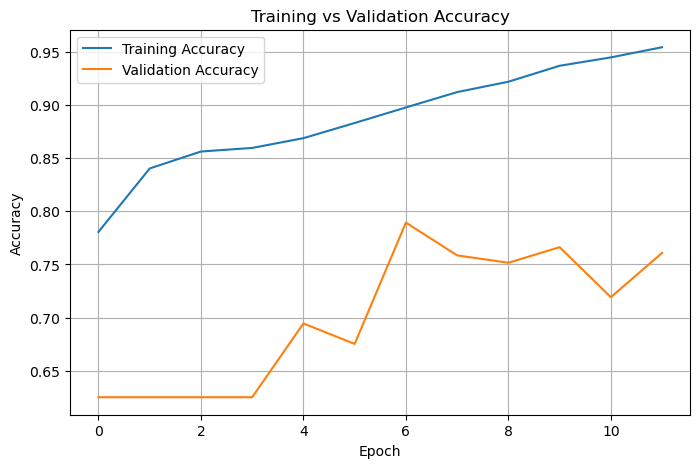

In [21]:
## Training and Validation Performance

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

**Observation:**
The training accuracy gradually increased to 95.44%, while the validation accuracy reached a maximum of 78.94%. The gap between training and validation accuracy indicates some overfitting, so EarlyStopping was used to retain the best model weights.

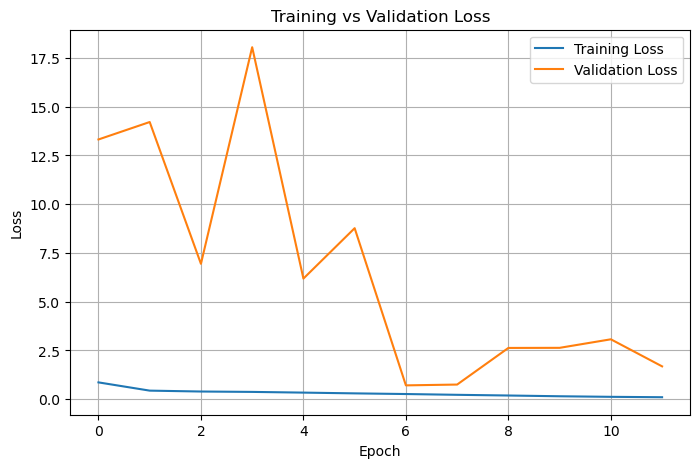

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

**Observation:**
The training loss gradually decreased throughout the training process. The validation loss reached its minimum at Epoch 7, after which it fluctuated while training loss continued to decrease. Therefore, EarlyStopping was used to retain the best model weights.

## 19.Evlauate the Final CNN Model

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test_final,
    y_test_final,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.7971 - loss: 0.6154
Test Loss: 0.6154
Test Accuracy: 79.71 %


**Observation:**
The trained CNN model was evaluated on the unseen test dataset. It achieved a test accuracy of 79.71% with a test loss of 0.6154, showing that the model can distinguish between genuine and forged signatures with reasonable performance.

## 20.Confusion Matrix

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step


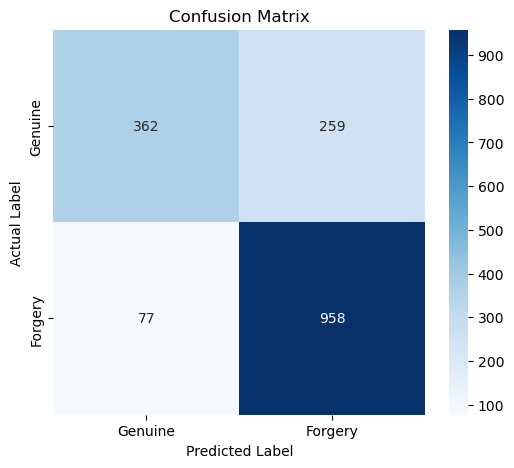

In [24]:
y_pred_prob = model.predict(X_test_final)

y_pred = (y_pred_prob > 0.5).astype(int).ravel()

cm = confusion_matrix(y_test_final, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Forgery'],
    yticklabels=['Genuine', 'Forgery']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

**Observation:**
The confusion matrix shows that the model correctly classified 362 genuine signatures and 958 forged signatures. It misclassified 259 genuine signatures as forgery and 77 forged signatures as genuine. Overall, the model achieved 79.71% test accuracy.

## 21.Classification Report

In [25]:
print("Classification Report:\n")

print(
    classification_report(
        y_test_final,
        y_pred,
        target_names=['Genuine', 'Forgery']
    )
)

Classification Report:

              precision    recall  f1-score   support

     Genuine       0.82      0.58      0.68       621
     Forgery       0.79      0.93      0.85      1035

    accuracy                           0.80      1656
   macro avg       0.81      0.75      0.77      1656
weighted avg       0.80      0.80      0.79      1656



**Observation:**
The classification report shows an overall test accuracy of 79.71%. For genuine signatures, the model achieved 82% precision and 58% recall. For forged signatures, it achieved 79% precision and 93% recall. The higher recall for forgery indicates that the model identifies most forged signatures correctly.

## 22.Single Signature Predicition

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


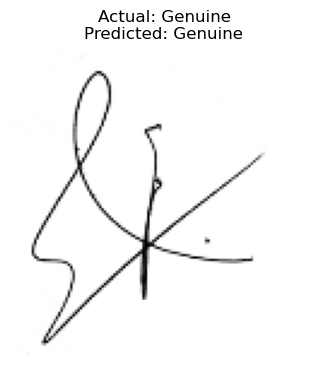

Actual Label    : Genuine
Predicted Label : Genuine
Prediction Probability: 0.2192


In [26]:
import matplotlib.pyplot as plt

# Select one test image
sample_image = X_test_final[0]
actual_label = y_test_final[0]

# Predict
prediction_prob = model.predict(sample_image.reshape(1, 128, 128, 1))[0][0]

predicted_label = 1 if prediction_prob > 0.5 else 0

# Display
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.axis('off')

actual_name = "Forgery" if actual_label == 1 else "Genuine"
predicted_name = "Forgery" if predicted_label == 1 else "Genuine"

plt.title(f"Actual: {actual_name}\nPredicted: {predicted_name}")
plt.show()

print("Actual Label    :", actual_name)
print("Predicted Label :", predicted_name)
print("Prediction Probability:", round(prediction_prob, 4))

**Observation:**
For a sample test signature, the model correctly predicted it as genuine. The predicted forgery probability was 21.92%, which is below the 0.5 classification threshold, so the signature was classified as genuine.


## 23.Conclusion:
1.The Signature Verification Using Deep Learning project successfully developed a CNN-based model to classify signature images as genuine or forged.

2.The model achieved a test accuracy of **79.71%** on unseen signature images. The confusion matrix and classification report were used to evaluate the model in detail.

3.The model also successfully performed single-signature prediction, demonstrating its ability to classify new signature images.


## 24.Project Limitations
1.The model achieved **79.71%** accuracy, so some signatures are still misclassified.
    
2.Genuine signatures had **58%** recall, meaning some genuine signatures were classified as forgery.
    
3.The model was trained on a specific signature dataset, so performance may vary on completely different datasets.
Image quality, size and writing variations can affect prediction.

## 25.Future Enchancements
1.Use a larger and more diverse signature dataset.

2.Apply data augmentation to improve generalization.

3.Experiment with transfer learning models such as MobileNet, ResNet or EfficientNet.

4.Improve the model's ability to recognize genuine signatures.

5.Deploy the model as a web or mobile application for real-time signature verification.